In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cargar los 4 datasets SISMEPRE
df_original   = pd.read_csv('SISMEPRE_CAPA_SILVER.csv', encoding='latin-1')
df_simple     = pd.read_parquet('sismepre_silver_simple.parquet')
df_intermedio = pd.read_parquet('sismepre_silver_intermedio.parquet')
df_avanzado   = pd.read_parquet('sismepre_silver_avanzado.parquet')

datasets = {
    "Original":   df_original,
    "Simple":     df_simple,
    "Intermedio": df_intermedio,
    "Avanzado":   df_avanzado
}

print("✅ Datasets SISMEPRE cargados correctamente")
for nombre, df in datasets.items():
    print(f"   {nombre:<12}: {len(df):,} registros, {len(df.columns)} columnas")

✅ Datasets SISMEPRE cargados correctamente
   Original    : 100,000 registros, 27 columnas
   Simple      : 100,000 registros, 27 columnas
   Intermedio  : 31,875 registros, 28 columnas
   Avanzado    : 13,024 registros, 27 columnas


In [2]:
# Eliminar columnas temporales generadas durante la limpieza
columnas_temp = ['NIVEL_NOMBRE_ESPERADO', 'ANO_ORIGEN']

for nombre, df_temp in datasets.items():
    for col in columnas_temp:
        if col in df_temp.columns:
            df_temp.drop(columns=[col], inplace=True)

print("✅ Columnas temporales eliminadas")

✅ Columnas temporales eliminadas


In [3]:
import numpy as np

# Clave de negocio para duplicados SISMEPRE
cols_duplicados = ['SEC_EJEC', 'ANO_APLICACION', 'PREGUNTA_ID']

def get_quality_metrics(df):
    existing_cols = [col for col in cols_duplicados if col in df.columns]

    decimal_neg = (df['RESPUESTA_DECIMAL'] < 0).sum() \
                  if 'RESPUESTA_DECIMAL' in df.columns else 0
    entero_neg  = (df['RESPUESTA_ENTERO']  < 0).sum() \
                  if 'RESPUESTA_ENTERO'  in df.columns else 0
    ano_inv     = len(df[
                      (df['ANO_APLICACION'] < 2010) |
                      (df['ANO_APLICACION'] > 2026)
                  ]) if 'ANO_APLICACION' in df.columns else 0

    return {
        "registros":          len(df),
        "nulos":              df.isnull().sum().sum(),
        "duplicados":         df.duplicated(subset=existing_cols).sum()
                              if existing_cols else 0,
        "decimal_negativos":  decimal_neg,
        "entero_negativos":   entero_neg,
        "anos_invalidos":     ano_inv
    }

In [4]:
base_size  = len(df_original)
comparison = []

for nombre, df_temp in datasets.items():
    metrics = get_quality_metrics(df_temp)

    comparison.append({
        "Dataset":               nombre,
        "Registros":             metrics["registros"],
        "Pérdida (%)":           round(
            (base_size - metrics["registros"]) / base_size * 100, 2
        ),
        "Nulos":                 metrics["nulos"],
        "Duplicados":            metrics["duplicados"],
        "RESPUESTA_DECIMAL neg.": metrics["decimal_negativos"],
        "RESPUESTA_ENTERO neg.":  metrics["entero_negativos"],
        "ANO_APLICACION inv.":    metrics["anos_invalidos"]
    })

comparison_df = pd.DataFrame(comparison)

print("=" * 70)
print("   COMPARATIVA DE CALIDAD — SISMEPRE Municipalidades")
print("=" * 70)
display(comparison_df)

   COMPARATIVA DE CALIDAD — SISMEPRE Municipalidades


,Dataset,Registros,Pérdida (%),Nulos,Duplicados,RESPUESTA_DECIMAL neg.,RESPUESTA_ENTERO neg.,ANO_APLICACION inv.
0,Original,100000,0.00,0,68125,0,0,0
1,Simple,100000,0.00,0,68125,0,0,0
2,Intermedio,31875,68.12,0,0,0,0,0
3,Avanzado,13024,86.98,0,0,0,0,0


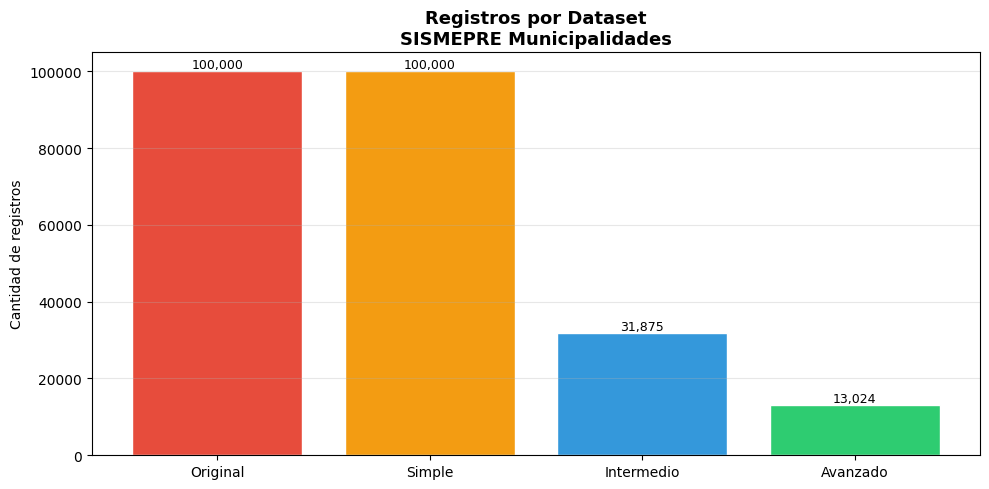

In [5]:
colores = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# Gráfico 1: Registros por dataset
plt.figure(figsize=(10, 5))
bars = plt.bar(comparison_df["Dataset"], comparison_df["Registros"],
               color=colores, edgecolor='white')
plt.title('Registros por Dataset\nSISMEPRE Municipalidades',
          fontsize=13, fontweight='bold')
plt.ylabel("Cantidad de registros")
plt.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, comparison_df["Registros"]):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 10,
             f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

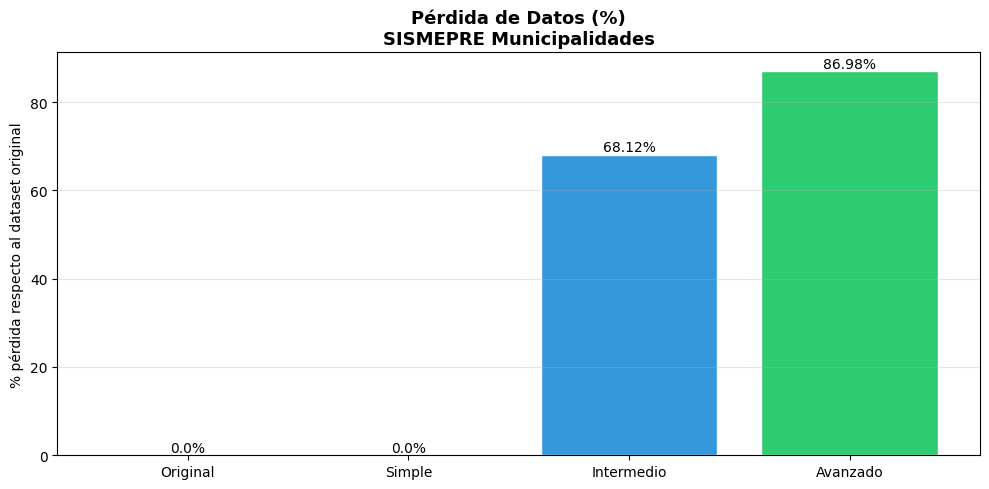

In [6]:
# Gráfico 2: Pérdida de datos por dataset
plt.figure(figsize=(10, 5))
bars = plt.bar(comparison_df["Dataset"], comparison_df["Pérdida (%)"],
               color=colores, edgecolor='white')
plt.title('Pérdida de Datos (%)\nSISMEPRE Municipalidades',
          fontsize=13, fontweight='bold')
plt.ylabel("% pérdida respecto al dataset original")
plt.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, comparison_df["Pérdida (%)"]):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{v}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

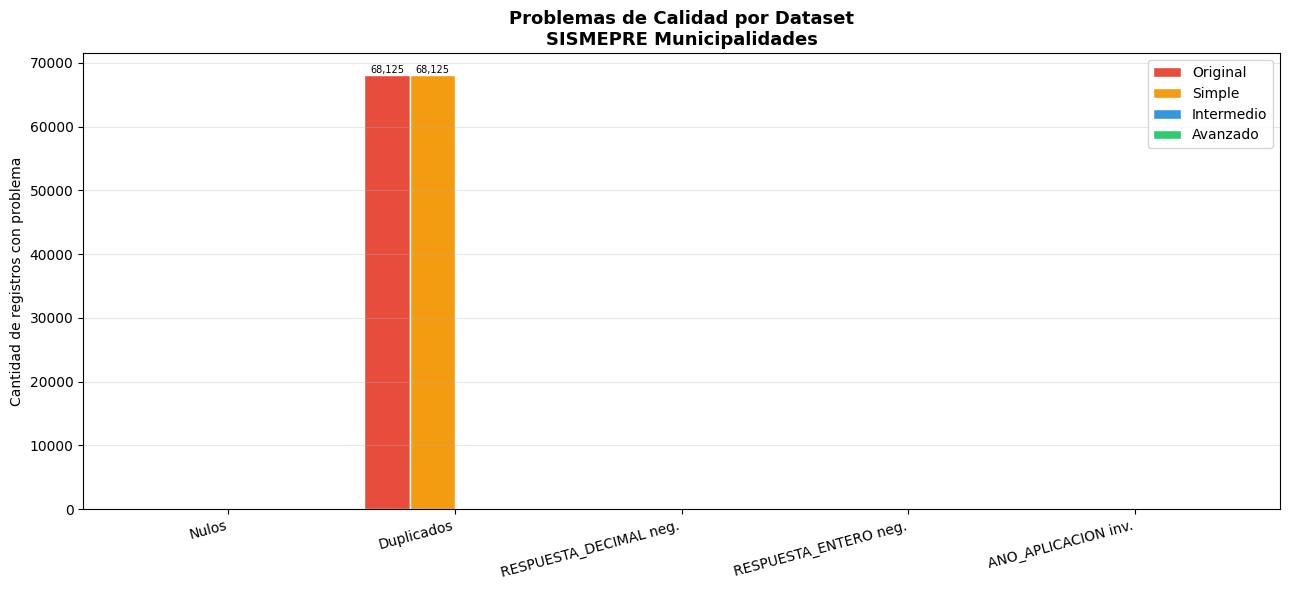

In [7]:
# Gráfico 3: Problemas de calidad por dataset
problemas_cols = [
    "Nulos",
    "Duplicados",
    "RESPUESTA_DECIMAL neg.",
    "RESPUESTA_ENTERO neg.",
    "ANO_APLICACION inv."
]

x     = np.arange(len(problemas_cols))
width = 0.2

plt.figure(figsize=(13, 6))

for i, (nombre, df_temp) in enumerate(datasets.items()):
    metrics = get_quality_metrics(df_temp)
    values  = [
        metrics["nulos"],
        metrics["duplicados"],
        metrics["decimal_negativos"],
        metrics["entero_negativos"],
        metrics["anos_invalidos"]
    ]
    bars = plt.bar(x + i * width, values, width,
                   label=nombre, color=colores[i], edgecolor='white')
    for bar, v in zip(bars, values):
        if v > 0:
            plt.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5,
                     f'{v:,}', ha='center', va='bottom', fontsize=7)

plt.xticks(x + width * 1.5, problemas_cols, rotation=15, ha='right')
plt.title('Problemas de Calidad por Dataset\nSISMEPRE Municipalidades',
          fontsize=13, fontweight='bold')
plt.ylabel("Cantidad de registros con problema")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

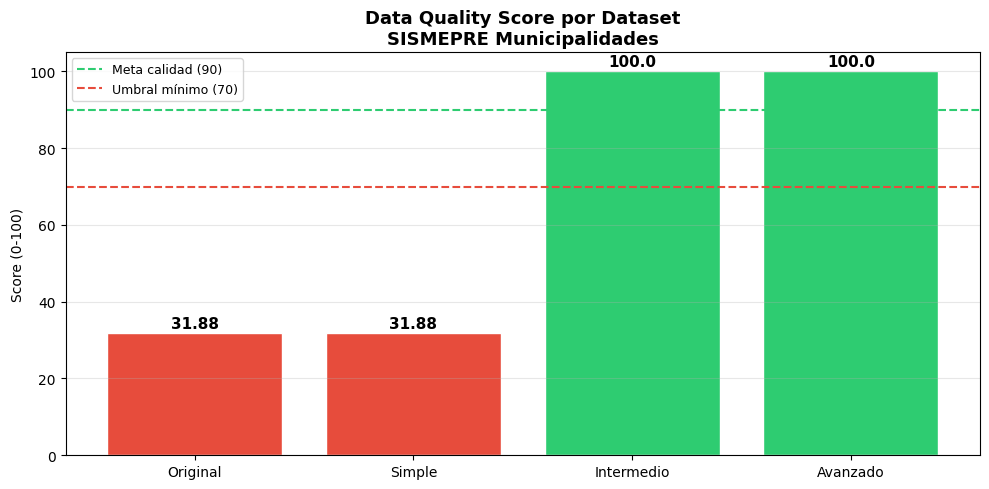


📊 Quality Scores SISMEPRE:
   Original    :  31.88 — 🔴 BAJO
   Simple      :  31.88 — 🔴 BAJO
   Intermedio  :  100.0 — 🟢 BUENO
   Avanzado    :  100.0 — 🟢 BUENO


In [8]:
def quality_score(metrics, total_rows):
    issues = (
        metrics["nulos"]             +
        metrics["duplicados"]        +
        metrics["decimal_negativos"] +
        metrics["entero_negativos"]  +
        metrics["anos_invalidos"]
    )
    score = max(0, 100 - (issues / total_rows * 100)) if total_rows > 0 else 0
    return round(score, 2)


scores = []

for nombre, df_temp in datasets.items():
    m     = get_quality_metrics(df_temp)
    score = quality_score(m, m["registros"])
    scores.append(score)

colores_score = [
    '#e74c3c' if s < 70 else '#f39c12' if s < 90 else '#2ecc71'
    for s in scores
]

plt.figure(figsize=(10, 5))
bars = plt.bar(datasets.keys(), scores,
               color=colores_score, edgecolor='white')
plt.axhline(y=90, color='#2ecc71', linestyle='--',
            linewidth=1.5, label='Meta calidad (90)')
plt.axhline(y=70, color='#e74c3c', linestyle='--',
            linewidth=1.5, label='Umbral mínimo (70)')
plt.title('Data Quality Score por Dataset\nSISMEPRE Municipalidades',
          fontsize=13, fontweight='bold')
plt.ylabel("Score (0-100)")
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.legend(fontsize=9)
for bar, v in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{v}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Quality Scores SISMEPRE:")
for nombre, score in zip(datasets.keys(), scores):
    estado = '🟢 BUENO' if score >= 90 else '🟡 REGULAR' if score >= 70 else '🔴 BAJO'
    print(f"   {nombre:<12}: {score:>6} — {estado}")